# Learning curves on an atmospheric molecule pool (MCM v3.3.1)

**Why.** The paper's central claim is that hand-crafted features sit near the learnable ceiling *at the data
scale available* (a few hundred real molecules). Since AIOMFAC is a free labeling oracle, that scale is a
choice, not a constraint. The Master Chemical Mechanism (MCM v3.3.1) contains about 3,400 closed-shell C/H/O/N
species that AIOMFAC represents with **no unmatched atoms**. All of them are real atmospheric oxidation
products, unlike the glass-former/pharmaceutical-heavy BIMOG set.

**What this notebook measures**

1. Learning curves of the feature-set-B MLP (paper Model A), trained on nested MCM subsets of 100 molecules up
   to the full MCM training set, and scored on (i) held-out MCM molecules and (ii) the paper's held-out BIMOG
   molecules.
2. The paper's own training set (BIMOG train, 312 molecules) with and without added MCM data: how well does
   the published surrogate transfer to atmospheric molecules?
3. Does a GNN (Part II architecture, GINE) catch up with the MLP once data is about 10× larger? This directly
   tests limitation 1 in Sec. 4.1.
4. BAT (Gorkowski et al., 2019) on held-out MCM molecules, the class of molecules BAT was designed for.

**Inputs.** `mcm_v331_species.tsv`: the MCM species export (all 143 primary VOCs, format "species TSV") from
https://mcm.york.ac.uk/MCM/export, plus `bimog_unified.json`. Cite the MCM website and the protocol papers
(Jenkin et al., 1997; Saunders et al., 2003) in the paper.

**Runtime.** With the default configuration, about 1–2 h on a 4-core CPU (GNN runs dominate). `FAST = True`
gives a quick first pass.

## 0) Setup

In [1]:
try:
    import aiomfac_py, rdkit, particula  # noqa: F401
    print("aiomfac_py, rdkit, particula available")
except ImportError:
    from pathlib import Path
    import subprocess
    REPO_DIR = Path("/content") / "aiomfac-python"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)], check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate --smiles")
    subprocess.run(["pip", "install", "-q", "rdkit", "particula"], check=True)

aiomfac_py, rdkit, particula available


In [2]:
import json, time, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from rdkit import Chem, RDLogger

import aiomfac_py as aiomfac
from aiomfac_py import ActivityModel, Component
from aiomfac_py.s2as import smiles_to_components
from aiomfac_py.params import load_subgroup_params
import aiomfac_py.s2as._mapping as _aiomfac_mapping
from particula.activity import bat_activity_coefficients
from particula.particles import get_organic_density_array

_aiomfac_mapping.print = lambda *args, **kwargs: None
RDLogger.DisableLog("rdApp.*")
sg = load_subgroup_params()

# ---- run configuration ----
FAST = False
SEEDS = (0,) if FAST else (0, 1, 2)
MCM_SIZES = (100, 300, 1000, None) if FAST else (100, 200, 400, 800, 1600, None)   # None = all MCM train
RUN_GNN = True
GNN_SIZES = (300, None) if FAST else (400, None)
MLP_MAX_EPOCHS, MLP_PATIENCE = 300, 30
print(f"aiomfac_py {aiomfac.__version__} | torch {torch.__version__} | threads {torch.get_num_threads()} | "
      f"seeds {SEEDS}")

aiomfac_py 0.0.24 | torch 2.14.1 | threads 4 | seeds (0, 1, 2)


## 1) Build the molecule pools

MCM filter: keep closed-shell species (no radical electrons, not flagged `Excited`, so no Criegee
intermediates) made only of C/H/O/N, with at least 2 heavy atoms, which s2as decomposes with **zero unmatched
atoms** and AIOMFAC evaluates. Any MCM molecule whose canonical SMILES also appears in BIMOG is dropped from MCM,
so that no molecule is in both pools.

In [3]:
def featurize(name, smi, category):
    '''SMILES -> pool record (same fields as Part I decompose_pool) or None if it fails any check.'''
    r = smiles_to_components([smi], water_as_component1=True)
    if r.removed:
        return None
    try:
        m = ActivityModel(r.components)
        if not (m.evaluate([0.9, 0.1], 298.15, basis="mass").gamma_neutral > 0).all():
            return None
    except Exception:
        return None
    mol = Chem.MolFromSmiles(smi)
    mol_h = Chem.AddHs(mol)
    sym = [a.GetSymbol() for a in mol_h.GetAtoms()]
    n_c = max(sym.count("C"), 1)
    return {"name": name, "smiles": smi, "canon": Chem.MolToSmiles(mol), "category": category,
            "subgroups": r.components[1].subgroups, "molar_mass_g_mol": sum(a.GetMass() for a in mol_h.GetAtoms()),
            "o_to_c": sym.count("O") / n_c, "n_to_c": sym.count("N") / n_c, "h_to_c": sym.count("H") / n_c,
            "n_unmatched": int(r.n_unmatched_atoms[0])}


def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    return ("bimog_n_and_hal" if has_n and has_hal else "bimog_n_only" if has_n
            else "bimog_hal_only" if has_hal else "bimog_cho")


with open("bimog_unified.json") as f:
    bimog = [o for d in json.load(f) if (o := featurize(d["name"], d["smiles"], bimog_category(d)))]
bimog_canon = {o["canon"] for o in bimog}

mcm_raw = pd.read_csv("mcm_v331_species.tsv", sep="\t", comment="*")
mcm, stats = [], {"total": len(mcm_raw)}
for _, row in mcm_raw.iterrows():
    mol = Chem.MolFromSmiles(str(row.Smiles))
    reason = None
    if str(row.Excited).lower() == "true":
        reason = "excited (Criegee)"
    elif mol is None:
        reason = "RDKit parse"
    elif any(a.GetNumRadicalElectrons() for a in mol.GetAtoms()):
        reason = "radical"
    elif not {a.GetSymbol() for a in mol.GetAtoms()} <= {"C", "H", "O", "N"} or \
            "C" not in {a.GetSymbol() for a in mol.GetAtoms()}:
        reason = "elements"
    elif mol.GetNumHeavyAtoms() < 2:
        reason = "too small"
    if reason is None:
        has_n = any(a.GetSymbol() == "N" for a in mol.GetAtoms())
        o = featurize(row.Name, str(row.Smiles), "mcm_n" if has_n else "mcm_cho")
        reason = ("s2as/AIOMFAC failed" if o is None else "unmatched atoms" if o["n_unmatched"] > 0
                  else "also in BIMOG" if o["canon"] in bimog_canon else None)
        if reason is None:
            mcm.append(o)
    stats[reason or "kept"] = stats.get(reason or "kept", 0) + 1
print("MCM filter:", stats)
print(f"BIMOG {len(bimog)} molecules | MCM {len(mcm)} molecules "
      f"({sum(o['category'] == 'mcm_n' for o in mcm)} N-containing)")

MCM filter: {'total': 5824, 'kept': 3337, 'radical': 2203, 'excited (Criegee)': 72, 'also in BIMOG': 72, 'elements': 139, 'too small': 1}
BIMOG 368 molecules | MCM 3337 molecules (1036 N-containing)


In [4]:
def is_test_molecule(smiles):                       # paper's split, unchanged
    return int(hashlib.sha256(smiles.encode()).hexdigest(), 16) % 100 < 15


pool = bimog + mcm
src = np.array(["bimog"] * len(bimog) + ["mcm"] * len(mcm))
is_test = np.array([is_test_molecule(o["smiles"]) for o in pool])
cat = np.array([o["category"] for o in pool])
mcm_train_ids = np.where((src == "mcm") & ~is_test)[0]
bimog_train_ids = np.where((src == "bimog") & ~is_test)[0]
TEST_SETS = {
    "MCM test": np.where((src == "mcm") & is_test)[0],
    "BIMOG test (paper)": np.where((src == "bimog") & is_test)[0],
    "BIMOG test, CHO only": np.where((cat == "bimog_cho") & is_test)[0],
}
print(f"train: MCM {len(mcm_train_ids)}, BIMOG {len(bimog_train_ids)} | "
      + ", ".join(f"{k}: {len(v)}" for k, v in TEST_SETS.items()))

# chemical-space overview (why BIMOG-trained models may not transfer)
desc = pd.DataFrame({"src": src, "M": [o["molar_mass_g_mol"] for o in pool], "O:C": [o["o_to_c"] for o in pool]})
display(desc.groupby("src").describe().T.round(2))

train: MCM 2855, BIMOG 312 | MCM test: 482, BIMOG test (paper): 56, BIMOG test, CHO only: 33


src          bimog      mcm
M   count   368.00  3337.00
    mean    219.05   166.00
    std     142.30    51.56
    min      32.04    26.04
    25%     115.68   130.19
    50%     161.57   160.17
    75%     316.58   195.13
    max    1153.00   353.20
O:C count   368.00  3337.00
    mean      0.26     0.70
    std       0.29     0.42
    min       0.00     0.00
    25%       0.08     0.40
    50%       0.17     0.60
    75%       0.33     0.86
    max       1.50     4.00

## 2) Labels, features and trainers

Labels follow Part I: 20 jittered w points × 4 temperatures per molecule. The feature-set-B vocabulary of
main groups is built over the union of both pools, so every model shares one feature space. The MLP trainer is
Part I's `train_and_eval`, with explicit seeding and with validation on 10 % of the training points. The GNN is
Part II's architecture (3-layer GINE, mean+sum pooling, 64-dim embedding, 2-layer head), written in plain
PyTorch so that `torch_geometric` is not needed.

In [5]:
def build_dataset(kept, seed=0, n_comp=20, n_temp=4):
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        m = ActivityModel([Component(1, "Water", ((16, 1),)), Component(2, "org", tuple(o["subgroups"]))])
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        for wtf_w in rng.uniform(edges[:-1], edges[1:]):
            for T in rng.uniform(273.15, 313.15, n_temp):
                try:
                    lg = m.evaluate([wtf_w, 1.0 - wtf_w], T, basis="mass").ln_gamma
                    if np.isfinite(lg[:2]).all():
                        rows.append((oi, wtf_w, T, lg[0], lg[1]))
                except Exception:
                    continue
    return np.array(rows)


t0 = time.time()
data = build_dataset(pool)
PT_MOL = data[:, 0].astype(int)
X_COMP_T = np.column_stack([data[:, 1], (data[:, 2] - 293.15) / 20.0]).astype(np.float32)
Y = data[:, 3:5].astype(np.float32)
pts_of = {}
for i, oi in enumerate(PT_MOL):
    pts_of.setdefault(oi, []).append(i)
pts_of = {k: np.array(v) for k, v in pts_of.items()}
print(f"{len(Y)} labeled points in {time.time()-t0:.0f}s")

MAIN_GROUPS = sorted({sg.main_group(int(s)) for o in pool for s, q in o["subgroups"]})
def rich_features(kept):
    mg_index = {g: i for i, g in enumerate(MAIN_GROUPS)}
    feat = []
    for o in kept:
        mg, tq = np.zeros(len(MAIN_GROUPS)), 0
        for s, q in o["subgroups"]:
            mg[mg_index[sg.main_group(int(s))]] += q
            tq += q
        feat.append([*(mg / max(tq, 1)), o["o_to_c"], o["n_to_c"], np.log(o["molar_mass_g_mol"]), np.log1p(tq)])
    return np.array(feat, dtype=np.float32)
FEAT = rich_features(pool)
X_ALL = np.concatenate([FEAT[PT_MOL], X_COMP_T], axis=1)
print("feature dim (molecule + w, T):", X_ALL.shape[1])

296400 labeled points in 23s
feature dim (molecule + w, T): 29


In [6]:
class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


def points(mol_ids):
    return np.concatenate([pts_of[m] for m in mol_ids])


def score(err_by_pt, test_sets):
    out = {}
    for name, ids in test_sets.items():
        p = points(ids)
        out[f"{name} | water"] = float(err_by_pt[p, 0].mean())
        out[f"{name} | organic"] = float(err_by_pt[p, 1].mean())
    return out


def train_mlp(train_mols, seed, max_epochs=MLP_MAX_EPOCHS, patience=MLP_PATIENCE, batch=256):
    rng = np.random.RandomState(seed)
    torch.manual_seed(seed)
    tr = points(train_mols); rng.shuffle(tr)
    n_val = int(0.1 * len(tr)); val, fit = tr[:n_val], tr[n_val:]
    x_mean, x_std = X_ALL[fit].mean(0), X_ALL[fit].std(0)
    # Features that are constant in the training set (functional groups never seen in training) are left
    # unscaled; dividing by ~1e-6 would blow up predictions for any test molecule carrying that group.
    n_const = int((x_std < 1e-3).sum())
    x_std = np.where(x_std < 1e-3, 1.0, x_std)
    y_mean, y_std = Y[fit].mean(0), Y[fit].std(0) + 1e-6
    Xn = torch.tensor((X_ALL - x_mean) / x_std); Yn = torch.tensor((Y - y_mean) / y_std)
    model = MLPHead(X_ALL.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best, best_state, bad = float("inf"), None, 0
    fit_t, val_t = torch.tensor(fit), torch.tensor(val)
    for epoch in range(max_epochs):
        model.train()
        perm = fit_t[torch.from_numpy(rng.permutation(len(fit)))]
        for s in range(0, len(perm), batch):
            idx = perm[s:s + batch]
            opt.zero_grad(); loss_fn(model(Xn[idx]), Yn[idx]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xn[val_t]), Yn[val_t]).item()
        if v < best - 1e-5:
            best, best_state, bad = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        pred = model(Xn).numpy() * y_std + y_mean
    return np.abs(pred - Y), epoch + 1, n_const

In [7]:
# ---- GNN (Part II architecture) in plain PyTorch ----
ATOM_LIST = ["C", "O", "N", "Cl", "Br", "F", "I", "S"]
BOND_TYPES = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE, Chem.rdchem.BondType.TRIPLE,
              Chem.rdchem.BondType.AROMATIC]


def mol_graph(smi):
    mol = Chem.MolFromSmiles(smi)
    x = [[float(a.GetSymbol() == s) for s in ATOM_LIST] +
         [a.GetDegree() / 4.0, a.GetTotalNumHs() / 4.0, float(a.GetIsAromatic()), float(a.IsInRing()),
          a.GetFormalCharge()] for a in mol.GetAtoms()]
    ei, ea = [], []
    for b in mol.GetBonds():
        f = [float(b.GetBondType() == t) for t in BOND_TYPES]
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        ei += [(i, j), (j, i)]; ea += [f, f]
    if not ei:
        ei, ea = [(0, 0)], [[0.0] * 4]
    return np.array(x, np.float32), np.array(ei, np.int64).T, np.array(ea, np.float32)


GRAPHS = [mol_graph(o["smiles"]) for o in pool]


class GraphBank:
    '''Concatenated graphs of a fixed molecule list; forward on the whole bank at once.'''
    def __init__(self, mol_ids):
        xs, eis, eas, owner, off = [], [], [], [], 0
        for k, m in enumerate(mol_ids):
            x, ei, ea = GRAPHS[m]
            xs.append(x); eis.append(ei + off); eas.append(ea); owner.append(np.full(len(x), k)); off += len(x)
        self.x = torch.tensor(np.concatenate(xs)); self.ei = torch.tensor(np.concatenate(eis, 1))
        self.ea = torch.tensor(np.concatenate(eas)); self.owner = torch.tensor(np.concatenate(owner))
        self.n = len(mol_ids)
        self.local = {m: k for k, m in enumerate(mol_ids)}


class GINE(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))

    def forward(self, h, ei, e):
        msg = torch.relu(h[ei[0]] + e)
        agg = torch.zeros_like(h).index_add_(0, ei[1], msg)
        return self.mlp(h + agg)


class GNNModel(nn.Module):
    def __init__(self, hidden=64, emb=64, n_layers=3):
        super().__init__()
        self.atom_proj = nn.Linear(len(ATOM_LIST) + 5, hidden)
        self.edge_proj = nn.ModuleList([nn.Linear(4, hidden) for _ in range(n_layers)])
        self.convs = nn.ModuleList([GINE(hidden) for _ in range(n_layers)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.out = nn.Linear(2 * hidden, emb)
        self.head = nn.Sequential(nn.Linear(emb + 2, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(),
                                  nn.Linear(128, 2))

    def embed(self, bank):
        h = self.atom_proj(bank.x)
        for conv, bn, ep in zip(self.convs, self.bns, self.edge_proj):
            h = torch.relu(bn(conv(h, bank.ei, ep(bank.ea))))
        s = torch.zeros(bank.n, h.shape[1]).index_add_(0, bank.owner, h)
        cnt = torch.zeros(bank.n).index_add_(0, bank.owner, torch.ones(len(h))).clamp(min=1)
        return self.out(torch.cat([s / cnt[:, None], s], 1))


def train_gnn(train_mols, seed, max_epochs=40, patience=6, batch=1024):
    rng = np.random.RandomState(seed); torch.manual_seed(seed)
    tr = points(train_mols); rng.shuffle(tr)
    n_val = int(0.1 * len(tr)); val, fit = tr[:n_val], tr[n_val:]
    y_mean, y_std = Y[fit].mean(0), Y[fit].std(0) + 1e-6
    Yn = torch.tensor((Y - y_mean) / y_std); C = torch.tensor(X_COMP_T)
    bank = GraphBank(list(train_mols))
    loc = torch.tensor([bank.local.get(m, -1) for m in range(len(pool))])
    model = GNNModel(); opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss(); best, best_state, bad = float("inf"), None, 0
    P = torch.tensor(PT_MOL)
    def predict(bank_, loc_, idx):
        emb = model.embed(bank_)
        return model.head(torch.cat([emb[loc_[P[idx]]], C[idx]], 1))
    for epoch in range(max_epochs):
        model.train()
        perm = torch.tensor(fit[rng.permutation(len(fit))])
        for s in range(0, len(perm), batch):
            idx = perm[s:s + batch]
            opt.zero_grad(); loss_fn(predict(bank, loc, idx), Yn[idx]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(predict(bank, loc, torch.tensor(val)), Yn[val]).item()
        if v < best - 1e-5:
            best, best_state, bad = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state); model.eval()
    eval_mols = np.concatenate(list(TEST_SETS.values()))
    ebank = GraphBank(list(np.unique(eval_mols)))
    eloc = torch.tensor([ebank.local.get(m, 0) for m in range(len(pool))])
    err = np.full_like(Y, np.nan)
    with torch.no_grad():
        idx = torch.tensor(points(np.unique(eval_mols)))
        err[idx.numpy()] = np.abs(predict(ebank, eloc, idx).numpy() * y_std + y_mean - Y[idx.numpy()])
    return err, epoch + 1, 0

## 3) Run the learning curves

- **R1, MCM only.** Nested subsets of the MCM training molecules, taken in a seed-specific random order.
- **R2, BIMOG train + MCM.** The paper's training set (BIMOG train), alone or plus nested MCM subsets.
- **GNN.** The same R1 subsets at the sizes in `GNN_SIZES`.

In [8]:
runs, t0 = [], time.time()
def log(rec):
    runs.append(rec)
    print(f"  {rec['model']:4s} {rec['regime']:22s} n_train_mol={rec['n_train_mol']:5d} seed={rec['seed']} "
          f"MCM-test org={rec['MCM test | organic']:.3f}  BIMOG-test org={rec['BIMOG test (paper) | organic']:.3f} "
          f"({rec['epochs']} ep, {rec['n_unseen_feat']} unseen feat, {time.time()-t0:.0f}s)")

for seed in SEEDS:
    order = np.random.RandomState(100 + seed).permutation(mcm_train_ids)
    for n in MCM_SIZES:
        sub = order[: (n or len(order))]
        err, ep, nc = train_mlp(sub, seed)
        log({"model": "MLP", "regime": "R1: MCM only", "n_train_mol": len(sub), "seed": seed, "epochs": ep,
             "n_unseen_feat": nc,
             **score(err, TEST_SETS)})
    for n in (0, 400, 1600, None):
        sub = np.concatenate([bimog_train_ids, order[: (len(order) if n is None else n)]])
        err, ep, nc = train_mlp(sub, seed)
        log({"model": "MLP", "regime": "R2: BIMOG train + MCM", "n_train_mol": len(sub), "seed": seed,
             "epochs": ep, "n_unseen_feat": nc, **score(err, TEST_SETS)})
    if RUN_GNN:
        for n in GNN_SIZES:
            sub = order[: (n or len(order))]
            err, ep, nc = train_gnn(sub, seed)
            log({"model": "GNN", "regime": "R1: MCM only", "n_train_mol": len(sub), "seed": seed, "epochs": ep,
             "n_unseen_feat": nc,
                 **score(err, TEST_SETS)})
runs = pd.DataFrame(runs)
runs.to_csv("mcm_learning_curve_runs.csv", index=False)

  MLP  R1: MCM only           n_train_mol=  100 seed=0 MCM-test org=0.292  BIMOG-test org=2.094 (160 ep, 3 unseen feat, 4s)


  MLP  R1: MCM only           n_train_mol=  200 seed=0 MCM-test org=0.237  BIMOG-test org=1.751 (81 ep, 2 unseen feat, 8s)


  MLP  R1: MCM only           n_train_mol=  400 seed=0 MCM-test org=0.170  BIMOG-test org=1.402 (139 ep, 2 unseen feat, 19s)


  MLP  R1: MCM only           n_train_mol=  800 seed=0 MCM-test org=0.129  BIMOG-test org=1.343 (182 ep, 2 unseen feat, 49s)


  MLP  R1: MCM only           n_train_mol= 1600 seed=0 MCM-test org=0.110  BIMOG-test org=1.444 (96 ep, 2 unseen feat, 81s)


...

  MLP  R2: BIMOG train + MCM  n_train_mol=  712 seed=2 MCM-test org=0.165  BIMOG-test org=0.269 (132 ep, 0 unseen feat, 2418s)


  MLP  R2: BIMOG train + MCM  n_train_mol= 1912 seed=2 MCM-test org=0.111  BIMOG-test org=0.268 (168 ep, 0 unseen feat, 2485s)


  MLP  R2: BIMOG train + MCM  n_train_mol= 3167 seed=2 MCM-test org=0.097  BIMOG-test org=0.248 (136 ep, 0 unseen feat, 2589s)


  GNN  R1: MCM only           n_train_mol=  400 seed=2 MCM-test org=0.217  BIMOG-test org=1.736 (40 ep, 0 unseen feat, 2611s)


  GNN  R1: MCM only           n_train_mol= 2855 seed=2 MCM-test org=0.077  BIMOG-test org=1.155 (29 ep, 0 unseen feat, 3380s)


## 4) BAT on the same test molecules

In [9]:
def bat_err(mol_ids):
    p = points(mol_ids)
    M = np.array([pool[m]["molar_mass_g_mol"] for m in PT_MOL[p]])
    oc = np.array([pool[m]["o_to_c"] for m in PT_MOL[p]])
    hc = np.array([pool[m]["h_to_c"] for m in PT_MOL[p]])
    nc = np.array([pool[m]["n_to_c"] for m in PT_MOL[p]])
    w = X_COMP_T[p, 0]
    x_org = ((1 - w) / M) / ((1 - w) / M + w / 18.015)
    out = bat_activity_coefficients(18.015 / M, x_org, oc, get_organic_density_array(M, oc, hc, nc))
    with np.errstate(divide="ignore"):
        return np.abs(np.column_stack([np.log(out[4]), np.log(out[5])]) - Y[p]), oc

# BAT under/overflows (γ -> 0 or inf) for some very oxidized MCM species (O:C up to 4, outside its fitted
# range); MAE is computed over finite points and the excluded fraction is reported.
bat, bat_rows = {}, []
mcm_cho_test = np.array([m for m in TEST_SETS["MCM test"] if cat[m] == "mcm_cho"])
for name, ids in {**TEST_SETS, "MCM test, CHO only": mcm_cho_test}.items():
    e, oc = bat_err(ids)
    ok = np.isfinite(e).all(1)
    bat[name] = (e[ok, 0].mean(), e[ok, 1].mean())
    bat_rows.append({"test set": name, "BAT water": e[ok, 0].mean(), "BAT organic": e[ok, 1].mean(),
                     "median BAT organic": np.median(e[ok, 1]), "excluded (non-finite) %": 100 * (~ok).mean(),
                     "max O:C of excluded": oc[~ok].max() if (~ok).any() else np.nan})
display(pd.DataFrame(bat_rows).set_index("test set").round(3))

,BAT water,BAT organic,median BAT organic,excluded (non-finite) %,max O:C of excluded
test set,,,,,
MCM test,1.136,2.806,1.093,0.073,0.0
BIMOG test (paper),0.128,1.387,0.805,0.000,NaN
"BIMOG test, CHO only",0.102,1.025,0.634,0.000,NaN
"MCM test, CHO only",1.471,2.418,0.697,0.102,0.0


## 5) Summary table and figure

In [10]:
metric_cols = [c for c in runs.columns if "|" in c]
summ = runs.groupby(["model", "regime", "n_train_mol"])[metric_cols].agg(["mean", "std"])
def ms(col):
    return summ[(col, "mean")].round(3).astype(str) + " ± " + summ[(col, "std")].fillna(0).round(3).astype(str)
table = pd.DataFrame({c: ms(c) for c in ["MCM test | organic", "BIMOG test (paper) | organic",
                                          "BIMOG test, CHO only | organic", "MCM test | water"]})
display(table)
table.to_csv("mcm_learning_curve_summary.csv")

MCM test | organic  \
model regime                n_train_mol                      
GNN   R1: MCM only          400              0.211 ± 0.009   
                            2855             0.078 ± 0.007   
MLP   R1: MCM only          100              0.304 ± 0.011   
                            200              0.233 ± 0.007   
                            400              0.167 ± 0.009   
                            800              0.133 ± 0.005   
                            1600             0.109 ± 0.001   
                            2855             0.098 ± 0.001   
      R2: BIMOG train + MCM 312               0.832 ± 0.05   
                            712                0.16 ± 0.01   
                            1912             0.113 ± 0.002   
                            3167             0.098 ± 0.002   

                                        BIMOG test (paper) | organic  \
model regime                n_train_mol                                
GNN   R1: MCM only          400                        1.827 ± 0.265   
                            2855                       1.282 ± 0.113   
MLP   R1: MCM only          100                        2.088 ± 0.206   
                            200                        1.818 ± 0.267   
                            400                        1.511 ± 0.108   
                            800                         1.43 ± 0.087   
                            1600                       1.372 ± 0.087   
                            2855                       1.275 ± 0.026   
      R2: BIMOG train + MCM 312                        0.278 ± 0.044   
                            712                        0.267 ± 0.015   
                            1912                       0.255 ± 0.017   
                            3167                       0.254 ± 0.014   

                                        BIMOG test, CHO only | organic  \
model regime                n_train_mol                                  
GNN   R1: MCM only          400                          1.322 ± 0.104   
                            2855                         0.933 ± 0.139   
MLP   R1: MCM only          100                          1.736 ± 0.252   
                            200                          1.543 ± 0.262   
                            400                          1.174 ± 0.096   
                            800                          1.041 ± 0.115   
                            1600                         0.932 ± 0.053   
                            2855                          0.886 ± 0.04   
      R2: BIMOG train + MCM 312                          0.194 ± 0.016   
                            712                           0.192 ± 0.01   
                            1912                         0.182 ± 0.012   
                            3167                         0.184 ± 0.015   

                                        MCM test | water  
model regime                n_train_mol                   
GNN   R1: MCM only          400            0.032 ± 0.004  
                            2855           0.012 ± 0.001  
MLP   R1: MCM only          100            0.042 ± 0.002  
                            200            0.031 ± 0.004  
                            400            0.022 ± 0.001  
                            800              0.017 ± 0.0  
                            1600             0.014 ± 0.0  
                            2855             0.012 ± 0.0  
      R2: BIMOG train + MCM 312            0.129 ± 0.002  
                            712             0.02 ± 0.002  
                            1912             0.013 ± 0.0  
                            3167             0.012 ± 0.0

MCM test: MLP R1 fit  MAE = 3.38·N^-0.57 + 0.059
BIMOG test (paper): MLP R1 fit  MAE = 16.64·N^-0.63 + 1.178


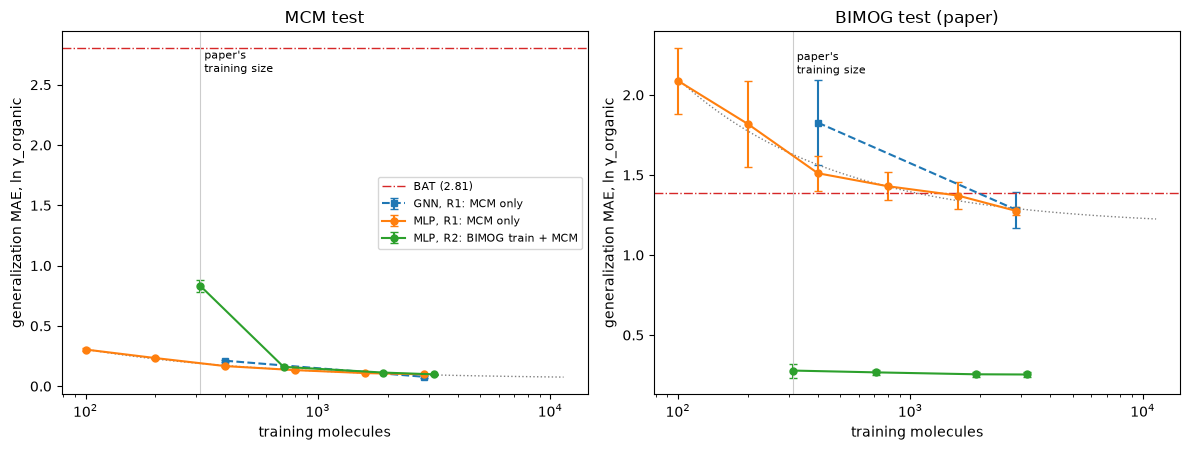

In [11]:
def power_law(n, a, b, c):
    return a * n ** (-b) + c

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
for ax, test in zip(axes, ["MCM test", "BIMOG test (paper)"]):
    col = f"{test} | organic"
    for (model, regime), g in runs.groupby(["model", "regime"]):
        s = g.groupby("n_train_mol")[col].agg(["mean", "std"])
        style = {"MLP": "-o", "GNN": "--s"}[model]
        ax.errorbar(s.index, s["mean"], yerr=s["std"], fmt=style, capsize=3, ms=5, label=f"{model}, {regime}")
        if model == "MLP" and regime.startswith("R1") and len(s) >= 4:
            try:
                p, _ = curve_fit(power_law, s.index.values.astype(float), s["mean"].values,
                                 p0=(1.0, 0.5, 0.05), bounds=([0, 0, 0], [np.inf, 3, 5]), maxfev=20000)
                nn_ = np.logspace(np.log10(s.index.min()), np.log10(s.index.max() * 4), 50)
                ax.plot(nn_, power_law(nn_, *p), ":", color="0.5", lw=1)
                print(f"{test}: MLP R1 fit  MAE = {p[0]:.2f}·N^-{p[1]:.2f} + {p[2]:.3f}")
            except RuntimeError:
                pass
    if test in bat:
        ax.axhline(bat[test][1], color="tab:red", lw=1, ls="-.", label=f"BAT ({bat[test][1]:.2f})")
    ax.axvline(len(bimog_train_ids), color="0.8", lw=0.8)
    ax.text(len(bimog_train_ids), ax.get_ylim()[1] * 0.95, " paper's\n training size", fontsize=8, va="top")
    ax.set_xscale("log"); ax.set_xlabel("training molecules"); ax.set_ylabel("generalization MAE, ln γ_organic")
    ax.set_title(test)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig("mcm_learning_curve.png", dpi=200); plt.show()

## 6) How to read the results (and what to change in the paper)

- **R1 slope and asymptote.** A curve still falling at N ≈ 3,000 means the paper's "near the learnable ceiling"
  claim is a statement about 300 molecules only, and Sec. 4.1/Conclusions should say so. A plateau supports the
  claim at a defensible scale.
- **R2 at N = 312 on the MCM test.** This is the published surrogate's accuracy on real atmospheric oxidation
  products, the number ACP readers will care about most. If it is much worse than R1 at a similar N, the
  BIMOG-trained model should not be presented as an atmospheric screening tool without MCM-type training data.
- **GNN vs MLP at full MCM size.** If the gap closes or reverses, limitation 1 in Sec. 4.1 becomes a result. If
  it persists at about 10× more data, the hand-crafted-feature conclusion is much stronger than before.
- **BAT on the MCM test.** This is the fair comparison, because the test molecules fall in BAT's design domain.